In [3]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

# Load imports from the src directory
sys.path.insert(0, "../..")

from progsnap2.spec.enums import MainTableColumns as Cols
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
from progsnap2.analytics.analytics_config import Granularity
from progsnap2.datasets import codeworkout, edwards #, codebench, cs1eng

# Select a dataset by setting the config variable
config = edwards.F21

datasets_dir = os.path.join('..', '..', '..', 'sample_data')
dataset_paths = {
    # Edwards 2019 datasets is split into two semesters
    'edwards_f19': os.path.join(datasets_dir, 'edwards', '2019'),
    'edwards_s19': os.path.join(datasets_dir, 'edwards', '2019'),
}

if config.name in dataset_paths:
    dataset_root_dir = dataset_paths[config.name]
else:
    # Most datasets follow a simple naming convention
    dataset_name, dataset_semester = config.name.split('_')
    dataset_root_dir = os.path.join('..', '..', '..', 'sample_data', dataset_name, dataset_semester)

dataset = config.load(dataset_root_dir)

In [7]:
# Shorten some config variables for convenience
problem_id_col = config.primary_problem_grouping_column
timestamp_col = config.primary_timestamp_column

In [8]:
# TODO: Replace this with config files!

# from progsnap2.analytics.preprocessors.edwards import TimeStampToDateTimePreprocessor, ClassSubsetPreprocessor
# from progsnap2.analytics.preprocessors.codebench import YAMLLinkURLPreprocessor, CodeBenchAddParentEventIDs
# from progsnap2.analytics.preprocessors.codeworkout import CodeWorkoutExtractErrorTypesPreprocessor
# from progsnap2.analytics.ps2_dataset import SortPreprocessor, FilterPreprocessor
# from progsnap2.spec.enums import EventType

# data_config_path = None
# problem_id_col = None
# timestamp_col = None
# idle_gap = None
# break_gap = None
# main_table_preprocessors = []
# link_table_preprocessors = []
# submit_event = EventType.Submit
# grades_link_table = "Subject"
# grades_col = None
# start_time = None
# end_time = None
# early_percentage = None
# assignment_ids = None
# compile_error_type_column = Cols.CompileMessageType
# compile_event = EventType.Compile
# compile_error_event = EventType.CompileError
# output_suffix = ''

# falconcode_f21_config = {
#     "config_path": "sample_data_configs/falconcode.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         FilterPreprocessor(Cols.TermID, "Fall 2021"),
#     ],
#     "early_percentage": 0.25,
# }

# # Note: Only Fall has compilation data; spring has no Run.Program events!
# edwards_s19_config = {
#     "config_path": "sample_data_configs/edwards2019.yaml",
#     "problem_id_col": Cols.AssignmentID,
#     "timestamp_col": Cols.ClientTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "mt_preprocessing_steps": [
#         # Don't need this, since I've done and cached it
#         # AddErrors2021Preprocessor(),
#         TimeStampToDateTimePreprocessor(),
#         # Make sure this comes last so Fall is correct
#         ClassSubsetPreprocessor("Spring"),
#     ],
#     # Compile error info is stored in the Run.Program event itself
#     "compile_event": EventType.RunProgram,
#     "end_time": "2019-02-25 00:00:00",
#     "early_percentage": 0.23,
#     "assignment_ids": ["p4s", "p5s"],  # Only 2 assignments
#     "grades_col": "exam2",
#     "output_suffix": "-s19",
# }

# edwards_f19_config = edwards_s19_config.copy()
# edwards_f19_config["mt_preprocessing_steps"] = edwards_s19_config["mt_preprocessing_steps"].copy()
# edwards_f19_config["mt_preprocessing_steps"][-1] = ClassSubsetPreprocessor("Fall")
# edwards_f19_config["end_time"] = "2019-10-13 00:00:00"
# edwards_f19_config["assignment_ids"] = ["p4f", "p5f"]
# edwards_f19_config["early_percentage"] = 0.42
# edwards_f19_config["output_suffix"] = "-f19"

# edwards2021_config = {
#     "config_path": "sample_data_configs/edwards2021.yaml",
#     "problem_id_col": Cols.AssignmentID,
#     "timestamp_col": Cols.ClientTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "mt_preprocessing_steps": [
#         # Don't need this, since I've done and cached it
#         # AddErrors2021Preprocessor(),
#         TimeStampToDateTimePreprocessor(),
#     ],
#     # Compile error info is stored in the Run.Program event itself
#     "compile_event": EventType.RunProgram,
#     "end_time": "2022-01-01 00:00:00",
#     "early_percentage": 0.4,
#     "assignment_ids": ["Assign6", "Assign7"],  # Only 2 assignments
#     "grades_col": "FinalScore",
# }

# cwo_s19_config = {
#     "config_path": "sample_data_configs/cwo_s19.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         SortPreprocessor(),
#         CodeWorkoutExtractErrorTypesPreprocessor(),
#     ],
#     "submit_event": EventType.RunProgram,
#     "grades_col": "X-Grade",
#     "early_percentage": 0.33,
# }

# cwo_f19_config = {
#     "config_path": "sample_data_configs/cwo_f19.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 5 * 60,
#     "break_gap": 30 * 60,
#     "mt_preprocessing_steps": [
#         SortPreprocessor(),
#         CodeWorkoutExtractErrorTypesPreprocessor(),
#     ],
#     "submit_event": EventType.RunProgram,
#     "grades_col": "X-Grade",
#     "early_percentage": 0.25,
# }

# codebench2024_config = {
#     "config_path": "sample_data_configs/codebench2024.yaml",
#     "problem_id_col": Cols.ProblemID,
#     "timestamp_col": Cols.ServerTimestamp,
#     "idle_gap": 30,
#     "break_gap": 3 * 60,
#     "link_preprocessing_steps": [YAMLLinkURLPreprocessor(True)],
#     "mt_preprocessing_steps": [
#         CodeBenchAddParentEventIDs(),
#     ],
#     "grades_link_table": "CourseSubject",
#     "grades_col": "final-grade",
#     "start_time": "2024-09-01 00:00:00",
#     "early_percentage": 0.28,
#     "compile_error_type_col": "ProgramErrorOutput",
#     "compile_event": EventType.Submit,
#     "compile_error_event": EventType.RunTest,
# }

# # config = cwo_f19_config
# # config = cwo_s19_config
# # config = codebench2024_config
# # config = edwards2021_config
# # config = edwards_s19_config
# # config = edwards_f19_config
# config = falconcode_f21_config
# locals().update(config)

In [9]:
main_table = dataset.get_main_table()
main_table.head()

c:\Users\twprice\Documents\GitHub\ProgSnap2\src\progsnap2\examples\../..\progsnap2\database\reader\csv_reader.py:24: DtypeWarning: Columns (0,6,7,8,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,EventID,SubjectID,AssignmentID,CodeStateSection,EventType,SourceLocation,EditType,InsertText,DeleteText,X-Metadata,ClientTimestamp,ToolInstances,CodeStateID,X-Compilable,CompileMessageData,CompileMessageType,ParentEventID,Score,ProblemID
1063827,1063827,Student30,Assign6,task1.py,File.Edit,0.0,Insert,# @@@@@@@@@@@@@@@@@@\n# CS1400 - 001\n# Assign...,NaN,NaN,2021-10-08 23:04:57.177000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN,Assign6
1063828,1063828,Student30,Assign6,task1.py,File.Edit,51.0,Insert,\n,NaN,NaN,2021-10-08 23:04:58.077000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN,Assign6
1063829,1063829,Student30,Assign6,task1.py,X-Action,NaN,NaN,NaN,NaN,Backspace,2021-10-08 23:05:00.285000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN,Assign6
1063830,1063830,Student30,Assign6,task1.py,File.Edit,50.0,Delete,NaN,?,NaN,2021-10-08 23:05:00.359000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN,Assign6
1063831,1063831,Student30,Assign6,task1.py,X-Action,NaN,NaN,NaN,NaN,Backspace,2021-10-08 23:05:00.435000+00:00,PC;PP 1.1.10,NaN,1.0,NaN,NaN,NaN,NaN,Assign6


In [13]:
if config.start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= config.start_time]
if config.end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= config.end_time]

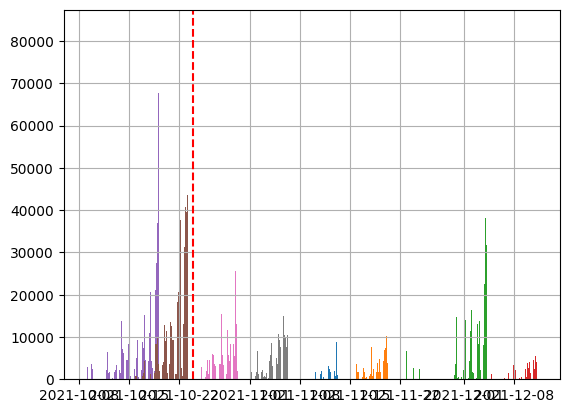

In [32]:
assignment_col = Cols.AssignmentID if Cols.AssignmentID in main_table.columns else problem_id_col
early_timestamp = pd.to_datetime(config.early_time)
if early_timestamp is None:
    print("Warning: No early time cutoff specified")
if Cols.CourseSectionID not in main_table.columns:
    main_table.groupby(assignment_col)[timestamp_col].hist(bins=100)
    if early_timestamp is not None:
        plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
else:
    classes = main_table[Cols.CourseSectionID].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table[Cols.CourseSectionID] == class_id]
        hist = subset.groupby(assignment_col)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        if early_timestamp is not None:
            plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
        plt.show()

In [15]:
main_table.AssignmentID.unique()

array(['Assign6', 'Assign7', 'Assign8', 'Assign9', 'Assign10', 'Assign11',
       'Assign12', 'Assign13'], dtype=object)

In [ ]:
# Used for converting percentages to raw early time when
# creating a dataset config; not needed when using existing configs
min = main_table.ClientTimestamp.min()
max = main_table.ClientTimestamp.max()
min + (max - min) * 0.4

Timestamp('2021-11-03 07:00:52.256200+0000', tz='UTC')

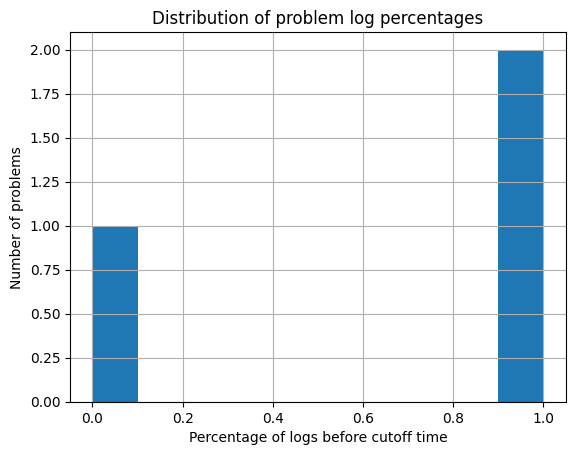

Removing partial problems: Index(['Assign8'], dtype='object', name='ProblemID')
This removed 0.01% of data
Semester start 2021-10-08 23:04:57.177000+00:00
Semester end 2021-12-11 06:54:44.875000+00:00
Early cutoff time 2021-10-24 00:00:00
Early Assignment IDs: ['Assign6' 'Assign7']
Early Problem IDs: ['Assign6' 'Assign7']
Total number of rows: 924552
Percent of logs:  44.12668442771219
Assignments: 2 / 8
Problems: 2 / 8


In [33]:
from progsnap2.analytics.preprocessors.early_cutoff import filter_before_time

data_subset = filter_before_time(main_table, config.early_time, timestamp_col, filter_problems=True, verbose=True)

In [34]:
# We want to analyze each student's attempt at each problem, and we also
# want to analyze data separately from each course section.
grouping_cols = config.attempt_grouping_columns
grouping_cols = [col for col in grouping_cols if col in main_table.columns]
grouping_cols

[<MainTableColumns.SubjectID: 'SubjectID'>,
 <MainTableColumns.AssignmentID: 'AssignmentID'>,
 <MainTableColumns.ProblemID: 'ProblemID'>]

In [35]:
from progsnap2.analytics.metrics.errors import ErrorMetrics

error_results = None

error_metrics = ErrorMetrics(True,
                             compile_message_type_column=config.compile_error_type_column,
                             compile_event=config.compile_event,
                             compile_error_event=config.compile_error_event)

error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
error_results.head()

C:\Users\twprice\AppData\Local\Temp\ipykernel_6180\3342469648.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)


ErrorQuotient  RepeatedErrorDensity  \
SubjectID AssignmentID ProblemID                                        
Student1  Assign6      Assign6              0.0                   0.0   
          Assign7      Assign7              0.0                   0.0   
Student10 Assign6      Assign6              0.0                   0.0   
          Assign7      Assign7              0.0                   0.0   
Student11 Assign6      Assign6              0.0                   0.0   

                                  FailedCompileCount  
SubjectID AssignmentID ProblemID                      
Student1  Assign6      Assign6                   5.0  
          Assign7      Assign7                  10.0  
Student10 Assign6      Assign6                   9.0  
          Assign7      Assign7                  32.0  
Student11 Assign6      Assign6                   8.0

In [36]:
# Distribution of each error metric across students/problems
error_results.describe()

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
count,77.000000,77.000000,78.000000
mean,0.000175,0.012987,28.512821
std,0.000958,0.080050,39.875372
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,6.000000
50%,0.000000,0.000000,13.000000
75%,0.000000,0.000000,32.750000
max,0.007737,0.500000,216.000000


In [37]:
# Correlate the metrics
error_results.corr(method="spearman")

,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
ErrorQuotient,1.000000,0.678201,0.258255
RepeatedErrorDensity,0.678201,1.000000,0.268347
FailedCompileCount,0.258255,0.268347,1.000000


<Axes: ylabel='Frequency'>

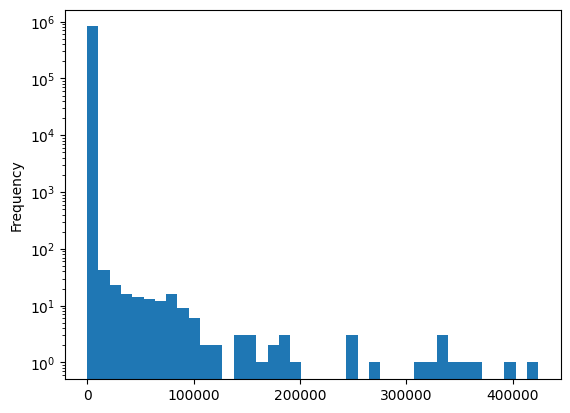

In [38]:
from progsnap2.analytics.metrics.time import TimeMetrics

# Out of curisosity, how far apart are events in this dataset (in seconds)?
diffs = TimeMetrics.get_all_diffs(data_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [39]:
# Determine a gap to be considered idle time or taking a break based
# on the type of dataset. Can confirm with the histogram above if it makes sense
idle_gap = None
break_gap = None
if config.granularity == Granularity.Submission:
    idle_gap = 5 * 60  # 5 minutes
    break_gap = 30 * 60  # 30 minutes
elif config.granularity == Granularity.Edit or config.granularity == Granularity.Keystroke:
    idle_gap = 30
    break_gap = 3 * 60 # 3 minutes
else:
    raise NotImplementedError(f"{config.granularity} granularity has not been determined.")


In [40]:
from progsnap2.analytics.metrics.time import TimeMetrics
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
time_results

C:\Users\twprice\AppData\Local\Temp\ipykernel_6180\1574692767.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  TotalTime  \
SubjectID AssignmentID ProblemID                                       
Student1  Assign6      Assign6      4070.057     3961.911   8031.968   
          Assign7      Assign7      2824.285     2617.328   5441.613   
Student10 Assign6      Assign6      4461.497     2510.514   6972.011   
          Assign7      Assign7      4303.607     2883.756   7187.363   
Student11 Assign6      Assign6      4017.941     2718.629   6736.570   
...                                      ...          ...        ...   
Student7  Assign7      Assign7      4396.574     1903.645   6300.219   
Student8  Assign6      Assign6      4575.533     2151.829   6727.362   
          Assign7      Assign7      5069.805     3451.084   8520.889   
Student9  Assign6      Assign6      7755.097     5634.013  13389.110   
          Assign7      Assign7     14471.103     8300.890  22771.993   

                                  ActiveTimeAfterCorrect  #Breaks  \
SubjectID AssignmentID ProblemID                                    
Student1  Assign6      Assign6                       0.0       22   
          Assign7      Assign7                       0.0       18   
Student10 Assign6      Assign6                       0.0       22   
          Assign7      Assign7                       0.0       13   
Student11 Assign6      Assign6                       0.0       17   
...                                                  ...      ...   
Student7  Assign7      Assign7                       0.0       14   
Student8  Assign6      Assign6                       0.0        8   
          Assign7      Assign7                       0.0        9   
Student9  Assign6      Assign6                       0.0       11   
          Assign7      Assign7                       0.0       28   

                                                        StartTime  \
SubjectID AssignmentID ProblemID                                    
Student1  Assign6      Assign6   2021-10-18 04:36:30.335000+00:00   
          Assign7      Assign7   2021-10-20 05:51:20.838000+00:00   
Student10 Assign6      Assign6   2021-10-10 18:13:46.376000+00:00   
          Assign7      Assign7   2021-10-21 02:57:43.909000+00:00   
Student11 Assign6      Assign6   2021-10-16 18:34:05.710000+00:00   
...                                                           ...   
Student7  Assign7      Assign7   2021-10-18 00:22:40.671000+00:00   
Student8  Assign6      Assign6   2021-10-18 16:00:54.951000+00:00   
          Assign7      Assign7   2021-10-20 18:35:20.667000+00:00   
Student9  Assign6      Assign6   2021-10-18 20:57:40.382000+00:00   
          Assign7      Assign7   2021-10-20 17:35:38.487000+00:00   

                                                 FirstCorrectTime  \
SubjectID AssignmentID ProblemID                                    
Student1  Assign6      Assign6   2021-10-19 05:53:30.844000+00:00   
          Assign7      Assign7   2021-10-22 05:46:11.558000+00:00   
Student10 Assign6      Assign6   2021-10-14 23:38:06.118000+00:00   
          Assign7      Assign7   2021-10-22 20:17:27.192000+00:00   
Student11 Assign6      Assign6                                NaT   
...                                                           ...   
Student7  Assign7      Assign7   2021-10-22 03:32:38.294000+00:00   
Student8  Assign6      Assign6   2021-10-19 03:51:06.128000+00:00   
          Assign7      Assign7                                NaT   
Student9  Assign6      Assign6   2021-10-19 05:50:29.926000+00:00   
          Assign7      Assign7   2021-10-23 03:23:32.406000+00:00   

                                                          EndTime  
SubjectID AssignmentID ProblemID                                   
Student1  Assign6      Assign6   2021-10-19 05:53:30.844000+00:00  
          Assign7      Assign7   2021-10-22 05:46:11.558000+00:00  
Student10 Assign6      Assign6   2021-10-14 23:38:06.118000+00:00  
          Assign7      Assign7   2021-10-22 20:17:27.192000+00:

In [41]:
time_results.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks
count,78.000000,78.000000,78.000000,78.0,78.000000
mean,6763.587705,5413.845885,12177.433590,0.0,21.153846
std,3970.226101,3289.069703,6979.505973,0.0,14.974504
min,2.786000,0.000000,2.786000,0.0,1.000000
25%,4030.970000,2929.491000,7198.800500,0.0,11.000000
50%,6318.867000,4889.300500,11185.741500,0.0,17.500000
75%,8766.416250,7353.448750,16226.556750,0.0,27.500000
max,25022.087000,17697.087000,42719.174000,0.0,79.000000


In [42]:
time_results.corr(method="spearman")

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
ActiveTime,1.000000,0.836081,0.964365,NaN,0.614156,-0.136686,0.062806,0.079402
PassiveTime,0.836081,1.000000,0.945516,NaN,0.764556,-0.111522,0.103582,0.131591
TotalTime,0.964365,0.945516,1.000000,NaN,0.707296,-0.133929,0.082536,0.100115
ActiveTimeAfterCorrect,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
#Breaks,0.614156,0.764556,0.707296,NaN,1.000000,-0.391120,-0.078836,-0.066163
StartTime,-0.136686,-0.111522,-0.133929,NaN,-0.391120,1.000000,0.817793,0.805384
FirstCorrectTime,0.062806,0.103582,0.082536,NaN,-0.078836,0.817793,1.000000,1.000000
EndTime,0.079402,0.131591,0.100115,NaN,-0.066163,0.805384,1.000000,1.000000


In [43]:
from progsnap2.analytics.metrics.score import SubmissionScoreMetrics
from progsnap2.spec.enums import EventType

score_metrics = SubmissionScoreMetrics(config.submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


C:\Users\twprice\AppData\Local\Temp\ipykernel_6180\3695921909.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [44]:
subject_problem_score.head()

Attempts  FirstCorrect  EverCorrect  \
SubjectID AssignmentID ProblemID                                        
Student1  Assign6      Assign6           1          True         True   
          Assign7      Assign7           1          True         True   
Student10 Assign6      Assign6           1          True         True   
          Assign7      Assign7           1          True         True   
Student11 Assign6      Assign6           0         False        False   

                                  Attempted  MaxScore  MinScore  MeanScore  \
SubjectID AssignmentID ProblemID                                             
Student1  Assign6      Assign6         True      99.0      99.0       99.0   
          Assign7      Assign7         True      99.0      99.0       99.0   
Student10 Assign6      Assign6         True      95.0      95.0       95.0   
          Assign7      Assign7         True     100.0     100.0      100.0   
Student11 Assign6      Assign6        False       0.0       0.0        0.0   

                                  TotalAttempts  
SubjectID AssignmentID ProblemID                 
Student1  Assign6      Assign6                1  
          Assign7      Assign7                1  
Student10 Assign6      Assign6                1  
          Assign7      Assign7                1  
Student11 Assign6      Assign6                0

In [45]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts
count,78.000000,75.000000,75.000000,75.000000,78.000000
mean,0.974359,74.880000,74.880000,74.880000,0.974359
std,0.159085,34.108416,34.108416,34.108416,0.159085
min,0.000000,-50.000000,-50.000000,-50.000000,0.000000
25%,1.000000,68.000000,68.000000,68.000000,1.000000
50%,1.000000,89.000000,89.000000,89.000000,1.000000
75%,1.000000,99.500000,99.500000,99.500000,1.000000
max,1.000000,100.000000,100.000000,100.000000,1.000000


In [46]:
all_features = pd.merge(
    time_results.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
if error_results is not None:
    all_features = pd.merge(
        all_features,
        error_results.reset_index(),
        on=grouping_cols,
        how="outer"
    )
all_features.head()

,SubjectID,AssignmentID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount
0,Student1,Assign6,Assign6,4070.057,3961.911,8031.968,0.0,22,2021-10-18 04:36:30.335000+00:00,2021-10-19 05:53:30.844000+00:00,...,True,True,True,99.0,99.0,99.0,1,0.0,0.0,5.0
1,Student1,Assign7,Assign7,2824.285,2617.328,5441.613,0.0,18,2021-10-20 05:51:20.838000+00:00,2021-10-22 05:46:11.558000+00:00,...,True,True,True,99.0,99.0,99.0,1,0.0,0.0,10.0
2,Student10,Assign6,Assign6,4461.497,2510.514,6972.011,0.0,22,2021-10-10 18:13:46.376000+00:00,2021-10-14 23:38:06.118000+00:00,...,True,True,True,95.0,95.0,95.0,1,0.0,0.0,9.0
3,Student10,Assign7,Assign7,4303.607,2883.756,7187.363,0.0,13,2021-10-21 02:57:43.909000+00:00,2021-10-22 20:17:27.192000+00:00,...,True,True,True,100.0,100.0,100.0,1,0.0,0.0,32.0
4,Student11,Assign6,Assign6,4017.941,2718.629,6736.570,0.0,17,2021-10-16 18:34:05.710000+00:00,NaT,...,False,False,False,0.0,0.0,0.0,0,0.0,0.0,8.0


In [47]:
# Some features are NA for some students, e.g. because
# they never got a problem right (no FirstCorrectTime) or
# because they only compiled once and errors metrics are undefined.
all_features.isna().mean()

SubjectID                 0.000000
AssignmentID              0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.115385
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.038462
MinScore                  0.038462
MeanScore                 0.038462
TotalAttempts             0.000000
ErrorQuotient             0.012821
RepeatedErrorDensity      0.012821
FailedCompileCount        0.000000
dtype: float64

In [48]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)

# We can calculate a few custom metrics
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,Attempts,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,78.000000,78.000000,78.000000,78.0,78.000000,78.000000,75.000000,75.000000,75.000000,78.000000,77.000000,77.000000,78.000000,78.000000,78.000000,78.000000
mean,6763.587705,5413.845885,12177.433590,0.0,21.153846,0.974359,74.880000,74.880000,74.880000,0.974359,0.000175,0.012987,28.512821,0.512821,0.500000,0.743590
std,3970.226101,3289.069703,6979.505973,0.0,14.974504,0.159085,34.108416,34.108416,34.108416,0.159085,0.000958,0.080050,39.875372,0.503071,0.503236,0.439477
min,2.786000,0.000000,2.786000,0.0,1.000000,0.000000,-50.000000,-50.000000,-50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4030.970000,2929.491000,7198.800500,0.0,11.000000,1.000000,68.000000,68.000000,68.000000,1.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.250000
50%,6318.867000,4889.300500,11185.741500,0.0,17.500000,1.000000,89.000000,89.000000,89.000000,1.000000,0.000000,0.000000,13.000000,1.000000,0.500000,1.000000
75%,8766.416250,7353.448750,16226.556750,0.0,27.500000,1.000000,99.500000,99.500000,99.500000,1.000000,0.000000,0.000000,32.750000,1.000000,1.000000,1.000000
max,25022.087000,17697.087000,42719.174000,0.0,79.000000,1.000000,100.000000,100.000000,100.000000,1.000000,0.007737,0.500000,216.000000,1.000000,1.000000,1.000000


In [49]:
# Let's take the z-score per problem for each numeric feature to
# normalize the features before combining across problems.
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

all_features_z[time_cols] = all_features_z[time_cols].astype('int64') / 1e9
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [50]:
all_features_z.head()

,SubjectID,AssignmentID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,Student1,Assign6,Assign6,-0.769725,-0.363766,-0.601434,0.0,0.000000,0.736089,0.435813,...,0.831530,0.831530,0.831530,0.152499,0.000000,0.000000,-0.521995,-1.011561,1.059838,0.614894
1,Student1,Assign7,Assign7,-0.895733,-0.896751,-0.919061,0.0,-0.153606,-0.203139,0.242628,...,0.565510,0.565510,0.565510,0.169031,-0.278279,-0.246296,-0.783358,-1.014185,0.904458,0.536499
2,Student10,Assign6,Assign6,-0.640114,-0.849445,-0.788287,0.0,0.000000,-1.787346,0.435722,...,0.722655,0.722655,0.722655,0.152499,0.000000,0.000000,-0.184465,-1.011561,1.059838,0.614894
3,Student10,Assign7,Assign7,-0.594064,-0.823119,-0.708979,0.0,-0.516863,0.257428,0.242648,...,0.599228,0.599228,0.599228,0.169031,-0.278279,-0.246296,-0.350346,-1.014185,0.904458,0.536499
4,Student11,Assign6,Assign6,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476


In [51]:
merge_cols = grouping_cols.copy()
merge_cols.remove(Cols.ProblemID)
merge_cols.remove(Cols.AssignmentID)
merge_cols = [col for col in merge_cols if col in all_features_z.columns]

# Take the average across all problems for each student
subject_means = all_features_z.drop([Cols.ProblemID, Cols.AssignmentID], axis=1).groupby(merge_cols).mean()

# Sometimes there are no non-NA values for a student across all problems for a given
# feature and we need to deal with that.

# For EQ and RED having no attempts with a successful compile (and therefore a score)
# should give you the max (worst) value
for col in [ErrorMetrics.ERROR_QUOTIENT, ErrorMetrics.REPEATED_ERROR_DENSITY]:
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for score metrics, not trying a problem should lead to the minimum value
for col in [SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,,
Student1,-0.832729,-0.630258,-0.760247,0.0,-0.076803,0.266475,0.339220,0.087969,0.160765,1.0,...,0.698520,0.698520,0.698520,0.160765,-0.139139,-0.123148,-0.652677,-1.012873,0.982148,0.575696
Student10,-0.617089,-0.836282,-0.748633,0.0,-0.258432,-0.764959,0.339185,-1.907781,0.160765,1.0,...,0.660942,0.660942,0.660942,0.160765,-0.139139,-0.123148,-0.267405,-1.012873,0.982148,0.575696
Student11,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,-6.404940,0.0,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476
Student12,1.311090,2.680584,2.060824,0.0,3.048168,-0.500759,0.339231,0.343021,0.160765,1.0,...,0.232451,0.232451,0.232451,0.160765,0.348585,1.970369,2.540574,0.961711,-0.997821,0.575696
Student13,-0.923491,-0.006492,-0.495085,0.0,-0.249954,0.002468,0.435765,-1.861159,0.152499,1.0,...,0.123845,0.123845,0.123845,0.152499,0.000000,0.000000,-0.775143,-1.011561,-0.921598,-1.588476


In [52]:
# We can also take the sum of features across problems, which treats
# missing problems differently than the mean.
subject_totals = all_features_z.drop([Cols.ProblemID, Cols.AssignmentID], axis=1).groupby(merge_cols).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,...,MaxScore,MinScore,MeanScore,TotalAttempts,ErrorQuotient,RepeatedErrorDensity,FailedCompileCount,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,,
Student1,-1.665458,-1.260517,-1.520495,0.0,-0.153606,0.532949,0.678440,0.175938,0.321529,2,...,1.397039,1.397039,1.397039,0.321529,-0.278279,-0.246296,-1.305353,-2.025746,1.964296,1.151392
Student10,-1.234178,-1.672565,-1.497266,0.0,-0.516863,-1.529919,0.678370,-3.815561,0.321529,2,...,1.321883,1.321883,1.321883,0.321529,-0.278279,-0.246296,-0.534811,-2.025746,1.964296,1.151392
Student11,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,-6.404940,0,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476
Student12,2.622179,5.361168,4.121647,0.0,6.096337,-1.001518,0.678463,0.686043,0.321529,2,...,0.464902,0.464902,0.464902,0.321529,0.697169,3.940737,5.081149,1.923423,-1.995642,1.151392
Student13,-0.923491,-0.006492,-0.495085,0.0,-0.249954,0.002468,0.435765,-1.861159,0.152499,1,...,0.123845,0.123845,0.123845,0.152499,0.000000,0.000000,-0.775143,-1.011561,-0.921598,-1.588476


In [53]:
# Lets merge the means and totals into a single DataFrame
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Student1,-0.832729,-0.630258,-0.760247,0.0,-0.076803,0.266475,0.339220,0.087969,0.160765,...,1.397039,1.397039,1.397039,0.321529,-0.278279,-0.246296,-1.305353,-2.025746,1.964296,1.151392
1,Student10,-0.617089,-0.836282,-0.748633,0.0,-0.258432,-0.764959,0.339185,-1.907781,0.160765,...,1.321883,1.321883,1.321883,0.321529,-0.278279,-0.246296,-0.534811,-2.025746,1.964296,1.151392
2,Student11,-0.786981,-0.779804,-0.829791,0.0,-0.312442,0.254540,-2.241262,-0.730103,-6.404940,...,-1.863116,-1.863116,-1.863116,-6.404940,0.000000,0.000000,-0.268847,-1.011561,-0.921598,-1.588476
3,Student12,1.311090,2.680584,2.060824,0.0,3.048168,-0.500759,0.339231,0.343021,0.160765,...,0.464902,0.464902,0.464902,0.321529,0.697169,3.940737,5.081149,1.923423,-1.995642,1.151392
4,Student13,-0.923491,-0.006492,-0.495085,0.0,-0.249954,0.002468,0.435765,-1.861159,0.152499,...,0.123845,0.123845,0.123845,0.152499,0.000000,0.000000,-0.775143,-1.011561,-0.921598,-1.588476


In [54]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [55]:
# No feature should be NA at this point
assert subject_features.isna().mean().mean() == 0

In [56]:
# Take one last z-score across all students for each numeric feature
# This makes means and sums more comparable across students
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MaxScore_sum,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,Student1,-0.807513,-0.614539,-0.732036,0.0,-0.026953,0.263161,0.468176,0.124724,0.202407,...,1.006570,1.006570,1.006570,0.241933,-3.176562e-01,-2.811479e-01,-0.842852,-1.220241,1.204252,0.737199
1,Student10,-0.580125,-0.833573,-0.719853,0.0,-0.223374,-0.940392,0.468136,-2.329907,0.202407,...,0.952420,0.952420,0.952420,0.241933,-3.176562e-01,-2.811479e-01,-0.345321,-1.220241,1.204252,0.737199
2,Student11,-0.759273,-0.773528,-0.804990,0.0,-0.281783,0.249234,-2.452969,-0.881448,-5.900273,...,-1.342380,-1.342380,-1.342380,-4.819365,-2.304225e-17,-1.728168e-17,-0.173592,-0.609330,-0.565005,-1.017049
3,Student12,1.453097,2.905374,2.227353,0.0,3.352526,-0.632104,0.468189,0.438420,0.202407,...,0.334963,0.334963,0.334963,0.241933,7.958214e-01,4.498366e+00,3.280841,1.158605,-1.223470,0.737199
4,Student13,-0.903219,0.048617,-0.453874,0.0,-0.214205,-0.044902,0.577466,-2.272566,0.194724,...,0.089230,0.089230,0.089230,0.114747,-2.304225e-17,-1.728168e-17,-0.500501,-0.609330,-0.565005,-1.017049


In [59]:
# Get the grades to compare features to
grades = dataset.get_link_table(config.grades_link_table_name)
grades.head()

,SubjectID,Assign6,Assign7,Assign8,Assign9,Assign10,Assign11,Assign12,Assign13,Exam1,Exam2,Exam3,FinalScore,major,HighestACT,HighSchoolGPA
0,Student11,70.0,88.0,45.0,63.0,86.0,97.0,20.0,88.0,82.00,82.0,78.0,89.58,Non-Matriculated,NaN,NaN
1,Student23,100.0,100.0,100.0,98.0,0.0,91.0,94.0,0.0,74.00,78.0,82.0,90.98,Physics,28.0,4.000
2,Student21,90.0,96.0,98.0,95.0,77.0,0.0,97.0,56.0,68.67,78.0,80.0,90.79,Non-Matriculated,NaN,NaN
3,Student17,89.0,96.0,100.0,94.0,91.0,100.0,89.0,0.0,88.00,84.0,80.0,96.95,Statistics,26.0,3.933
4,Student7,100.0,100.0,99.5,97.0,100.0,95.0,98.0,18.0,90.00,90.0,86.0,100.52,Math/Stats - Comp Teaching,35.0,4.000


In [60]:
grades.rename(columns={
    config.final_grade_column: "Grade",
    # Edwards 2019 calls it Group
    # "Group": Cols.CourseSectionID,
    },
inplace=True)

# Drop 0 grades, since they're likely students who skipped the test
print(f"Dropping {grades[grades['Grade'] <= 0].shape[0]} rows with 0 grades")
grades = grades[grades["Grade"] > 0]

Dropping 0 rows with 0 grades


In [61]:
grade_merge_cols = [col for col in merge_cols if col in grades.columns]
print(f"Merging on columns: {grade_merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[grade_merge_cols + ["Grade"]],
    on=grade_merge_cols,
    how="inner",
)

Merging on columns: [<MainTableColumns.SubjectID: 'SubjectID'>]


In [62]:
print(subject_features.shape)
subject_feautres_labeled.head()

(44, 45)


,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,MinScore_sum,MeanScore_sum,TotalAttempts_sum,ErrorQuotient_sum,RepeatedErrorDensity_sum,FailedCompileCount_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum,Grade
0,Student1,-0.807513,-0.614539,-0.732036,0.0,-0.026953,0.263161,0.468176,0.124724,0.202407,...,1.006570,1.006570,0.241933,-3.176562e-01,-2.811479e-01,-0.842852,-1.220241,1.204252,0.737199,97.70
1,Student10,-0.580125,-0.833573,-0.719853,0.0,-0.223374,-0.940392,0.468136,-2.329907,0.202407,...,0.952420,0.952420,0.241933,-3.176562e-01,-2.811479e-01,-0.345321,-1.220241,1.204252,0.737199,97.60
2,Student11,-0.759273,-0.773528,-0.804990,0.0,-0.281783,0.249234,-2.452969,-0.881448,-5.900273,...,-1.342380,-1.342380,-4.819365,-2.304225e-17,-1.728168e-17,-0.173592,-0.609330,-0.565005,-1.017049,89.58
3,Student12,1.453097,2.905374,2.227353,0.0,3.352526,-0.632104,0.468189,0.438420,0.202407,...,0.334963,0.334963,0.241933,7.958214e-01,4.498366e+00,3.280841,1.158605,-1.223470,0.737199,95.73
4,Student13,-0.903219,0.048617,-0.453874,0.0,-0.214205,-0.044902,0.577466,-2.272566,0.194724,...,0.089230,0.089230,0.114747,-2.304225e-17,-1.728168e-17,-0.500501,-0.609330,-0.565005,-1.017049,94.52


In [63]:
subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().describe()

count    41.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: Grade, dtype: float64

In [64]:
assert subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().max() == 1

In [65]:

out_dir = os.path.join("..", "..", "..", "analysis", "features")
print(len(subject_feautres_labeled))
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
subject_feautres_labeled.to_csv(os.path.join(out_dir, f"{config.name}.csv"), index=False)

41
